### Контрольная работа по дисциплине "Современный языки и технологии программирования" Тараева Маргарита Витальевна ВИИМ32 Вариант 10

In [3]:
from sympy import *
init_printing(use_latex=True)

##  1. Вычислить предел: $\lim\limits_{x\to\infty}(1+\frac{5}{x})^{3x}$

In [4]:
x = symbols('x')
y = Limit((1 + 5 / x) ** (3 * x), x, oo)
Eq(y, y.doit())

## Задание 1. Найти предел функции
$$\lim_{x\to\infty}\left(\dfrac{2x^2+3}{2x^2+5}\right)^{8x^2+3}$$

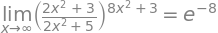

In [5]:
x = symbols('x')
y = Limit(((2*x**2 + 3) / (2*x**2 + 5)) ** (8*x**2 + 3), x, oo)
Eq(y, y.doit())

## Задание 2. Вычислить неопределённый интеграл
$$\int \arccos x \, dx$$

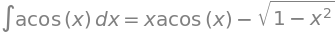

In [6]:
Fx = Integral(acos(x), x)
Eq(Fx, Fx.doit())

Проверим результат дифференцированием:

In [7]:
Fx.diff(x)

## Задание 3. Решить систему линейных уравнений
$$
\begin{cases}
x_1+2x_2+3x_3+4x_4=11,\\
2x_1+3x_2+4x_3+x_4=12,\\
3x_1+4x_2+x_3+2x_4=13,\\
4x_1+x_2+2x_3+3x_4=14.
\end{cases}
$$

In [8]:
x1, x2, x3, x4 = symbols('x1 x2 x3 x4')
eq1 = Eq(x1 + 2*x2 + 3*x3 + 4*x4, 11)
eq2 = Eq(2*x1 + 3*x2 + 4*x3 + x4, 12)
eq3 = Eq(3*x1 + 4*x2 + x3 + 2*x4, 13)
eq4 = Eq(4*x1 + x2 + 2*x3 + 3*x4, 14)
eq1, eq2, eq3, eq4

In [9]:
linsolve([eq1, eq2, eq3, eq4], [x1, x2, x3, x4])

Система имеет единственное решение: $x_1=2,\ x_2=1,\ x_3=1,\ x_4=1$.

## Задание 4. Исследовать функцию и построить график
$$y=\dfrac{x}{1+x^2}$$

Функция определена на всей вещественной оси (знаменатель не обращается в нуль), нечётная: $y(-x)=-y(x)$, график симметричен относительно начала координат. Горизонтальная асимптота $y=0$, вертикальных асимптот нет.

In [10]:
def y(x):
    return x / (1 + x**2)

x = symbols('x', real=True)

Точки пересечения с осями координат:

In [11]:
rt = solve(y(x), x)
print('Решение уравнения y(x)=0:')
rt

Решение уравнения y(x)=0:


In [12]:
vx = [rt[0]]
vy = [0]
vx.append(0)
vy.append(y(0))
print('Точки пересечения с осями координат:')
vx, vy

Точки пересечения с осями координат:


Находим производные:

Первая производная:


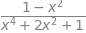

In [13]:
y1 = diff(y(x), x)
print('Первая производная:')
y1 = simplify(y1)
y1

Вторая производная:


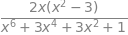

In [14]:
y2 = diff(y1, x)
print('Вторая производная:')
y2 = simplify(y2)
y2

#### Исследование на экстремум

In [15]:
ext = solve(y1, x)
print('Стационарные точки: ')
ext

Стационарные точки: 


In [16]:
y2.subs(x, ext[0])
# важен знак второй производной в первой стационарной точке

In [17]:
y2.subs(x, ext[1])
# важен знак второй производной во второй стационарной точке

В точке $x=-1$ вторая производная положительна — локальный минимум, $y(-1)=-1/2$.
В точке $x=1$ вторая производная отрицательна — локальный максимум, $y(1)=1/2$.

#### Исследование на перегиб

In [18]:
per = solve(y2, x)
print('Точки перегиба: ')
per

Точки перегиба: 


Итак, собираем координаты всех характерных точек графика исследуемой функции:

In [19]:
for p in ext:
    vx.append(p)
    vy.append(y(p))
for p in per:
    vx.append(p)
    vy.append(y(p))
print(vx, vy)

[0, 0, -1, 1, 0, -sqrt(3), sqrt(3)] [0, 0.0, -1/2, 1/2, 0, -sqrt(3)/4, sqrt(3)/4]


Строим график:

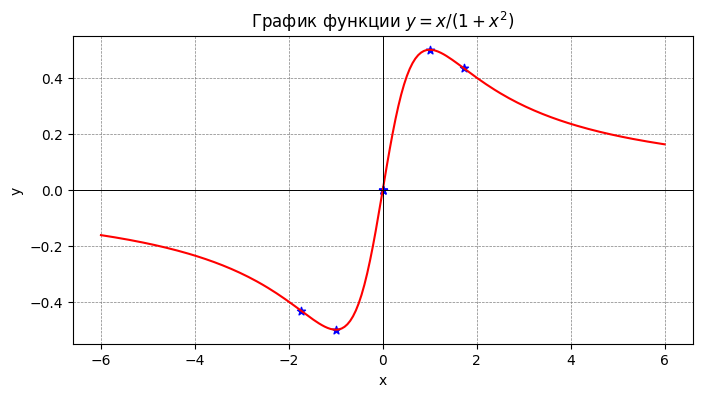

In [20]:
import matplotlib.pyplot as plt
import numpy as np

X = np.linspace(-6, 6, 200)
Y = [float(y(xi)) for xi in X]

vx_f = [float(v) for v in vx]
vy_f = [float(v) for v in vy]

fig = plt.figure(figsize=(8, 4), dpi=100)
plt.plot(X, Y, color='red', linewidth=1.5)
plt.scatter(vx_f, vy_f, marker='*', c='blue')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'График функции $y = x/(1+x^2)$')
plt.axhline(0, color='black', linewidth=0.7)
plt.axvline(0, color='black', linewidth=0.7)
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()

## Задание 5. Найти общее решение дифференциального уравнения
$$\frac{y}{x}\,y' = e^{x-y}$$

In [21]:
x = symbols('x')
f = Function('y')
deq = Eq(f(x) / x * f(x).diff(x), exp(x - f(x)))
deq

Уравнение с разделяющимися переменными. Решение по умолчанию:

In [22]:
dsolve(deq, f(x))

Результат выражен через неэлементарную функцию LambertW() и неудобен для практики. Посмотрим, какими ещё методами можно решить уравнение:

In [23]:
classify_ode(deq, f(x))

('factorable',
 'separable',
 '1st_power_series',
 'lie_group',
 'separable_Integral')

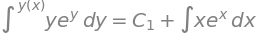

In [24]:
dsolve(deq, f(x), hint='separable_Integral')

Разделяем переменные явно: $y\,e^{y}\,dy = x\,e^{x}\,dx$ и вычисляем интегралы по отдельности:

In [25]:
yv = symbols('y')
F1 = Integral(yv * exp(yv), yv)
F2 = Integral(x * exp(x), x)
Eq(F1.doit(), F2.doit())

Таким образом, общее решение (с точностью до произвольной постоянной $C$):
$$(y-1)e^{y} = (x-1)e^{x} + C$$